# TextileGuard Model Notebook (Single Source of Truth)

This notebook contains the full ML model workflow and replaces the backend model scripts.

Sections:
- Dependencies and paths
- Dataset checks and optional synthetic generation
- TensorFlow and CUDA diagnostics
- MobileNetV2 training (v2) with evaluation
- Legacy CNN training
- Prediction utilities
- Quick synthetic training

Outputs (model, plots, reports) are saved to backend/saved_model under this project root.

In [ ]:
# Install required dependencies
# NOTE: After this cell runs for the first time, restart the kernel,
#       then run all cells again (the restart is skipped on subsequent runs).
import sys
import subprocess
import importlib

REQUIRED = {
    'tensorflow': 'tensorflow>=2.13.0',
    'matplotlib': 'matplotlib>=3.7.0',
    'numpy': 'numpy>=1.24.0',
    'sklearn': 'scikit-learn>=1.3.0',
    'pillow': 'pillow>=10.0.0',
}

missing = [pkg for mod in REQUIRED if importlib.util.find_spec(mod) is None for pkg in [REQUIRED[mod]]]
if missing:
    print(f'Installing: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('Installation complete. Restarting kernel...')
    # Auto-restart kernel so newly installed packages are importable
    try:
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
    except Exception:
        print('Please manually restart the kernel now, then re-run all cells.')
else:
    print('All dependencies already installed.')

All dependencies already installed.


In [ ]:
import os
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


def _resolve_project_root(start_dir):
    candidates = [start_dir]
    for i in range(1, 5):
        candidates.append(os.path.abspath(os.path.join(start_dir, *(['..'] * i))))
    for p in candidates:
        if os.path.isdir(os.path.join(p, 'dataset')) and os.path.isdir(os.path.join(p, 'backend')):
            return p
    return start_dir


# Update this path to your Drive project folder if using Colab
DEFAULT_ROOT = ('/content/drive/MyDrive/Textile-Pattern-Defect-Detection-System'
                if IN_COLAB else _resolve_project_root(os.getcwd()))
DRIVE_ROOT = os.environ.get('TEXTILE_GUARD_ROOT', DEFAULT_ROOT)

DATASET_DIR = os.path.join(DRIVE_ROOT, 'dataset')
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
TEST_DIR = os.path.join(DATASET_DIR, 'test')
SAVED_MODEL_DIR = os.path.join(DRIVE_ROOT, 'backend', 'saved_model')

MODEL_PATH = os.path.join(SAVED_MODEL_DIR, 'textile_defect_model.keras')
HISTORY_PATH = os.path.join(SAVED_MODEL_DIR, 'training_history.json')
PLOT_PATH = os.path.join(SAVED_MODEL_DIR, 'training_plot.png')
CONFUSION_PATH = os.path.join(SAVED_MODEL_DIR, 'confusion_matrix.png')
REPORT_PATH = os.path.join(SAVED_MODEL_DIR, 'evaluation_report.json')

os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}


def _has_images(folder):
    if not os.path.isdir(folder):
        return False
    for name in os.listdir(folder):
        _, ext = os.path.splitext(name)
        if ext.lower() in IMAGE_EXTS:
            return True
    return False


# Set True to auto-generate a synthetic dataset when train folders are empty
AUTO_GENERATE_DATASET = True
SYNTHETIC_SCRIPT = os.path.join(DRIVE_ROOT, 'dataset', 'generate_dataset_v2.py')

# Sanity check dataset structure (train required, test optional)
required = [
    os.path.join(TRAIN_DIR, 'defective'),
    os.path.join(TRAIN_DIR, 'non_defective'),
]
missing_required = [p for p in required if not _has_images(p)]

if missing_required and AUTO_GENERATE_DATASET:
    if not os.path.exists(SYNTHETIC_SCRIPT):
        raise FileNotFoundError(f'Synthetic dataset script not found: {SYNTHETIC_SCRIPT}')
    print('Dataset folders are empty. Generating synthetic dataset...')
    subprocess.check_call([sys.executable, SYNTHETIC_SCRIPT])
    import gc; gc.collect()  # free memory used by dataset generation before TF loads
    missing_required = [p for p in required if not _has_images(p)]

if missing_required:
    raise FileNotFoundError(
        'Missing or empty required dataset folder(s):\n'
        + '\n'.join(missing_required)
        + '\n\nSet DRIVE_ROOT to the correct project folder '
        + '(or set TEXTILE_GUARD_ROOT env var).'
        + '\nIf you want synthetic data, ensure AUTO_GENERATE_DATASET = True.'
    )

test_folders = [
    os.path.join(TEST_DIR, 'defective'),
    os.path.join(TEST_DIR, 'non_defective'),
]
HAS_TEST_SET = all(os.path.exists(p) and _has_images(p) for p in test_folders)
if not HAS_TEST_SET:
    print('Test set not found or empty; validation split will be reused as test.')

print(f'Project root : {DRIVE_ROOT}')
print(f'Train dir    : {TRAIN_DIR}')
print(f'Has test set : {HAS_TEST_SET}')
print('Dataset structure looks OK.')

Project root : c:\Users\ks759\mini projec\Textile-Pattern-Defect-Detection-System
Train dir    : c:\Users\ks759\mini projec\Textile-Pattern-Defect-Detection-System\dataset\train
Has test set : True
Dataset structure looks OK.


If you still see a ModuleNotFoundError after running the install cell, restart the runtime/kernel and run the setup cells again.

In [ ]:
# Dataset diagnostics (class counts + sample grid)
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)
image_exts = IMAGE_EXTS if "IMAGE_EXTS" in globals() else {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

def _list_images(folder):
    if not os.path.isdir(folder):
        return []
    return [
        os.path.join(folder, name)
        for name in os.listdir(folder)
        if os.path.splitext(name)[1].lower() in image_exts
    ]


def _print_counts(label, counts):
    total = sum(counts.values())
    print(f"{label} total: {total}")
    for cls in sorted(counts):
        pct = (counts[cls] / total * 100.0) if total else 0.0
        print(f"  {cls:14}: {counts[cls]:4d} ({pct:5.1f}%)")
    if total and len(counts) == 2:
        cls_a, cls_b = sorted(counts)
        ratio = counts[cls_a] / max(1, counts[cls_b])
        print(f"  imbalance ratio ({cls_a}/{cls_b}): {ratio:.2f}")


train_counts = {}
test_counts = {}
for cls in ("defective", "non_defective"):
    train_counts[cls] = len(_list_images(os.path.join(TRAIN_DIR, cls)))
    test_counts[cls] = len(_list_images(os.path.join(TEST_DIR, cls)))

_print_counts("Train", train_counts)
_print_counts("Test", test_counts)

# Sample grid from training data
samples_per_class = 3
classes = ["defective", "non_defective"]
rows = len(classes)
cols = samples_per_class
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
if rows == 1:
    axes = [axes]
for i, cls in enumerate(classes):
    cls_folder = os.path.join(TRAIN_DIR, cls)
    cls_images = _list_images(cls_folder)
    if cls_images:
        cls_samples = random.sample(cls_images, k=min(samples_per_class, len(cls_images)))
    else:
        cls_samples = []
    for j in range(cols):
        ax = axes[i][j]
        ax.axis("off")
        if j < len(cls_samples):
            img = Image.open(cls_samples[j]).convert("RGB")
            ax.imshow(img)
        if j == 0:
            ax.set_title(cls)
plt.tight_layout()
plt.show()

## MobileNetV2 training (v2)

The next cells define the model, training pipeline, and evaluation.

In [3]:
import os
import json
import numpy as np

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# ── GPU / CPU memory guard (MUST be set before TF initialises) ──────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
for _gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass
if not gpus:
    # CPU-only: cap thread count to avoid fork-bomb on Windows
    tf.config.threading.set_inter_op_parallelism_threads(2)
    tf.config.threading.set_intra_op_parallelism_threads(4)
print(f'TF {tf.__version__} | GPUs: {len(gpus)} | Device: {"GPU" if gpus else "CPU"}')
# ─────────────────────────────────────────────────────────────────────────
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Config (mirrors train_v2.py)
IMG_SIZE = 224
BATCH_SIZE = 32
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 15
PHASE1_LR = 1e-3
PHASE2_LR = 1e-5
FINE_TUNE_AT = -30
LABEL_SMOOTHING = 0.1
DROPOUT_RATE = 0.5
L2_WEIGHT = 1e-4
VALIDATION_SPLIT = 0.2
SEED = 42

TF 2.21.0 | GPUs: 0 | Device: CPU


In [ ]:
# CUDA / GPU diagnostics
import shutil
import subprocess
import tensorflow as tf

print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
build_info = tf.sysconfig.get_build_info()
cuda_ver = build_info.get("cuda_version", "unknown")
cudnn_ver = build_info.get("cudnn_version", "unknown")
print(f"TF build: CUDA {cuda_ver} | cuDNN {cudnn_ver}")

if shutil.which("nvidia-smi"):
    print("\n--- nvidia-smi ---")
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("nvidia-smi not found on PATH.")

In [4]:
def build_augmentation_layers():
    augment_layers = [
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.15),
        layers.RandomZoom((-0.1, 0.1)),
        layers.RandomContrast(0.15),
    ]
    if hasattr(layers, "RandomBrightness"):
        augment_layers.append(layers.RandomBrightness(0.15))
    return keras.Sequential(augment_layers, name='augmentation')


def build_model(num_classes=1):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    augmented = build_augmentation_layers()(inputs, training=True)

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=augmented,
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D(name='avg_pool')(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_WEIGHT), name='dense_head')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_WEIGHT), name='dense_head_2')(x)
    x = layers.Dropout(DROPOUT_RATE * 0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='prediction')(x)

    model = Model(inputs, outputs, name='textile_defect_mobilenetv2')
    return model, base_model

In [5]:
def load_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=VALIDATION_SPLIT,
        subset='training',
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='binary',
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=VALIDATION_SPLIT,
        subset='validation',
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='binary',
    )

    if HAS_TEST_SET:
        test_ds = tf.keras.utils.image_dataset_from_directory(
            TEST_DIR,
            image_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            label_mode='binary',
            shuffle=False,
        )
    else:
        print('Using validation set as test set (dataset/test missing or empty).')
        test_ds = val_ds

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    test_ds = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds

In [6]:
def save_training_plot(history, phase1_epochs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.get('accuracy', []), label='Train Accuracy', linewidth=2)
    axes[0].plot(history.get('val_accuracy', []), label='Val Accuracy', linewidth=2)
    axes[0].axvline(x=phase1_epochs - 0.5, color='red', linestyle='--', alpha=0.5, label='Fine-tune start')
    axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.get('loss', []), label='Train Loss', linewidth=2)
    axes[1].plot(history.get('val_loss', []), label='Val Loss', linewidth=2)
    axes[1].axvline(x=phase1_epochs - 0.5, color='red', linestyle='--', alpha=0.5, label='Fine-tune start')
    axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)
    plt.close()
    print(f'Training plot saved to {PLOT_PATH}')

In [7]:
def compute_class_weights(train_dir):
    """Compute inverse-frequency class weights to handle class imbalance."""
    import numpy as np
    class_counts = {}
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if os.path.isdir(cls_path):
            count = sum(1 for f in os.listdir(cls_path)
                        if os.path.splitext(f)[1].lower() in IMAGE_EXTS)
            class_counts[cls] = count
    total = sum(class_counts.values())
    n_classes = len(class_counts)
    print(f'  Class counts: {class_counts}')
    # Map class folder names to integer indices (sorted alphabetically, same as Keras)
    sorted_classes = sorted(class_counts.keys())
    weights = {
        i: total / (n_classes * max(1, class_counts[cls]))
        for i, cls in enumerate(sorted_classes)
    }
    print(f'  Class weights: {weights}')
    return weights


def train():
    print('============================================================')
    print('  TextileGuard Model Training v2 - MobileNetV2')
    print('============================================================')

    print('\n[*] Loading datasets...')
    train_ds, val_ds, test_ds = load_datasets()

    # FIX: compute class weights to address class imbalance
    print('\n[*] Computing class weights...')
    class_weight = compute_class_weights(TRAIN_DIR)

    print('\n[*] Building MobileNetV2 model...')
    model, base_model = build_model()
    model.summary(print_fn=lambda x: print(f'  {x}'))

    print('\n============================================================')
    print(f'  Phase 1: Feature Extraction (backbone frozen)')
    print(f'  LR={PHASE1_LR}, Epochs={PHASE1_EPOCHS}')
    print('============================================================')

    model.compile(
        optimizer=Adam(learning_rate=PHASE1_LR),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
        ],
    )

    phase1_callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True, verbose=1, mode='max'),
    ]

    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=PHASE1_EPOCHS,
        callbacks=phase1_callbacks,
        class_weight=class_weight,  # FIX: added to counteract class imbalance
    )

    print('\n============================================================')
    print(f'  Phase 2: Fine-Tuning (last {abs(FINE_TUNE_AT)} layers unfrozen)')
    print(f'  LR={PHASE2_LR}, Epochs={PHASE2_EPOCHS}')
    print('============================================================')

    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=PHASE2_LR),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
        ],
    )

    phase2_callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True, verbose=1, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ]

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=PHASE2_EPOCHS,
        callbacks=phase2_callbacks,
        class_weight=class_weight,  # FIX: added to counteract class imbalance
    )

    print('\n============================================================')
    print('  Evaluating on test set...')
    print('============================================================')

    best_model = keras.models.load_model(MODEL_PATH)
    test_results = best_model.evaluate(test_ds, return_dict=True)
    print('\n  Test Results:')
    for k, v in test_results.items():
        print(f'    {k}: {v:.4f}')

    y_true = []
    y_pred_proba = []
    for images, labels in test_ds:
        preds = best_model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred_proba.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    y_pred = (y_pred_proba > 0.5).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    cm = np.array([[tn, fp], [fn, tp]])

    accuracy = float((tp + tn) / max(1, tp + tn + fp + fn))
    precision = float(tp / max(1, tp + fp))
    recall = float(tp / max(1, tp + fn))
    f1 = float(2 * precision * recall / max(1e-8, precision + recall))

    report = {
        'test_accuracy': round(accuracy, 4),
        'test_precision': round(precision, 4),
        'test_recall': round(recall, 4),
        'test_f1': round(f1, 4),
        'confusion_matrix': {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp},
        'test_results': {k: round(float(v), 4) for k, v in test_results.items()},
    }
    with open(REPORT_PATH, 'w') as f:
        json.dump(report, f, indent=2)
    print(f'\n  Evaluation report saved to {REPORT_PATH}')

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Defective', 'Defective'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Non-Defective', 'Defective'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=18)
    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(CONFUSION_PATH, dpi=150)
    plt.close()
    print(f'  Confusion matrix saved to {CONFUSION_PATH}')

    combined_history = {}
    for key in history1.history:
        combined_history[key] = [float(v) for v in history1.history[key]]
        if key in history2.history:
            combined_history[key].extend([float(v) for v in history2.history[key]])

    with open(HISTORY_PATH, 'w') as f:
        json.dump(combined_history, f, indent=2)

    save_training_plot(combined_history, len(history1.history.get('accuracy', [])))

    print('\n============================================================')
    print('  [OK] Training complete!')
    print(f'  Model saved to : {MODEL_PATH}')
    print(f'  Accuracy  : {accuracy:.2%} | F1: {f1:.2%}')
    print(f'  Precision : {precision:.2%} | Recall: {recall:.2%}')
    print('============================================================')

## Run MobileNetV2 training

Run the next cell to start training and evaluation.

In [8]:
train()

  TextileGuard Model Training v2 - MobileNetV2

[*] Loading datasets...
Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Found 500 files belonging to 2 classes.

[*] Computing class weights...
  Class counts: {'defective': 1000, 'non_defective': 1000}
  Class weights: {0: 1.0, 1: 1.0}

[*] Building MobileNetV2 model...


C:\Users\ks759\AppData\Local\Temp\ipykernel_10244\1851299313.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


  Model: "textile_defect_mobilenetv2"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ augmentation[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 11

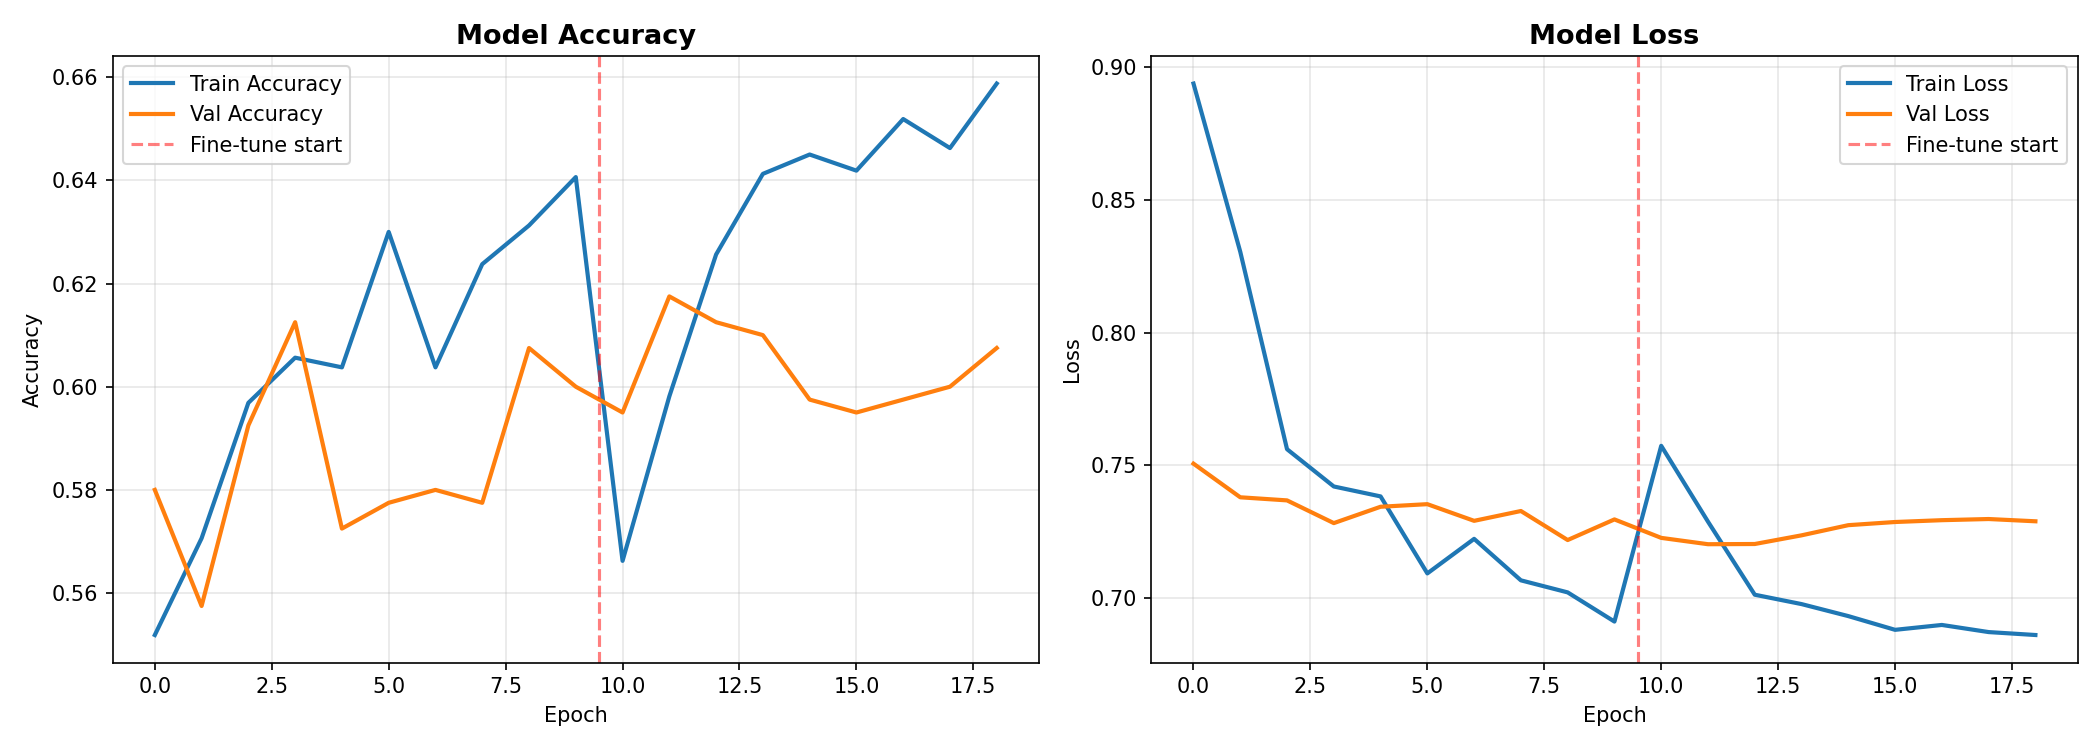

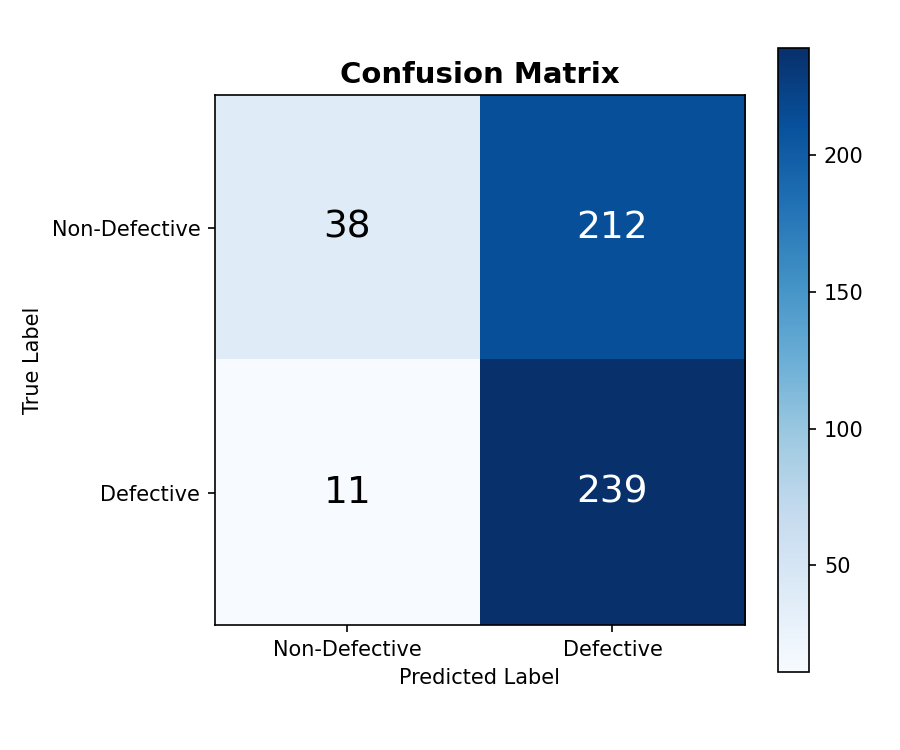

In [9]:
# Optional: display saved plots
from IPython.display import Image, display

if os.path.exists(PLOT_PATH):
    display(Image(filename=PLOT_PATH))

if os.path.exists(CONFUSION_PATH):
    display(Image(filename=CONFUSION_PATH))

# Additional model modules

These sections replace backend/model/preprocess.py, train.py, predict.py, and quick_train.py.
Backend model scripts are stubs; update this notebook instead.

In [ ]:
# Preprocessing utilities (from backend/model/preprocess.py)
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

LEGACY_IMG_HEIGHT = IMG_SIZE if "IMG_SIZE" in globals() else 224
LEGACY_IMG_WIDTH = IMG_SIZE if "IMG_SIZE" in globals() else 224
LEGACY_BATCH_SIZE = BATCH_SIZE if "BATCH_SIZE" in globals() else 32

NORMALIZATION_MODE = os.environ.get("NORMALIZATION_MODE", "efficientnet")

def get_data_generators(dataset_dir):
    """
    Create training, validation, and test generators with augmentation.
    """
    train_dir = os.path.join(dataset_dir, "train")
    test_dir = os.path.join(dataset_dir, "test")

    rescale_factor = None if NORMALIZATION_MODE == "efficientnet" else 1.0 / 255

    train_datagen = ImageDataGenerator(
        rescale=rescale_factor,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode="nearest",
        validation_split=0.2,
    )

    test_datagen = ImageDataGenerator(rescale=rescale_factor)

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(LEGACY_IMG_HEIGHT, LEGACY_IMG_WIDTH),
        batch_size=LEGACY_BATCH_SIZE,
        class_mode="binary",
        subset="training",
        shuffle=True,
    )

    val_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(LEGACY_IMG_HEIGHT, LEGACY_IMG_WIDTH),
        batch_size=LEGACY_BATCH_SIZE,
        class_mode="binary",
        subset="validation",
        shuffle=False,
    )

    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(LEGACY_IMG_HEIGHT, LEGACY_IMG_WIDTH),
        batch_size=LEGACY_BATCH_SIZE,
        class_mode="binary",
        shuffle=False,
    )

    return train_generator, val_generator, test_generator


def preprocess_single_image(image_path):
    """
    Preprocess a single image for prediction.
    """
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

    img = load_img(image_path, target_size=(LEGACY_IMG_HEIGHT, LEGACY_IMG_WIDTH))
    img_array = img_to_array(img)

    if NORMALIZATION_MODE != "efficientnet":
        img_array = img_array / 255.0

    return np.expand_dims(img_array, axis=0)

In [ ]:
# Legacy CNN training (from backend/model/train.py)
import json
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

LEGACY_EPOCHS = 20
LEGACY_LEARNING_RATE = 1e-4
LEGACY_IMG_HEIGHT = globals().get("LEGACY_IMG_HEIGHT", 224)
LEGACY_IMG_WIDTH = globals().get("LEGACY_IMG_WIDTH", 224)
LEGACY_DATASET_DIR = DATASET_DIR if "DATASET_DIR" in globals() else os.path.join(os.getcwd(), "dataset")
LEGACY_MODEL_PATH = MODEL_PATH if "MODEL_PATH" in globals() else os.path.join(os.getcwd(), "textile_defect_model.keras")
LEGACY_HISTORY_PATH = HISTORY_PATH if "HISTORY_PATH" in globals() else os.path.join(os.getcwd(), "training_history.json")
LEGACY_PLOT_PATH = PLOT_PATH if "PLOT_PATH" in globals() else os.path.join(os.getcwd(), "training_plot.png")

def build_legacy_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(LEGACY_IMG_HEIGHT, LEGACY_IMG_WIDTH, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.25),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEGACY_LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def save_legacy_training_plot(history_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history_dict["accuracy"], label="Train Accuracy")
    ax1.plot(history_dict["val_accuracy"], label="Val Accuracy")
    ax1.set_title("Model Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history_dict["loss"], label="Train Loss")
    ax2.plot(history_dict["val_loss"], label="Val Loss")
    ax2.set_title("Model Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(LEGACY_PLOT_PATH, dpi=150)
    plt.close()
    print(f"Training plot saved to {LEGACY_PLOT_PATH}")


def train_legacy_cnn(dataset_dir=None, epochs=None):
    dataset_dir = dataset_dir or LEGACY_DATASET_DIR
    epochs = epochs or LEGACY_EPOCHS

    train_dir = os.path.join(dataset_dir, "train")
    if not os.path.exists(train_dir):
        raise FileNotFoundError(f"Dataset not found at {dataset_dir}")

    train_gen, val_gen, test_gen = get_data_generators(dataset_dir)
    print(f"Classes: {train_gen.class_indices}")
    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Test samples: {test_gen.samples}")

    model = build_legacy_cnn_model()
    model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(LEGACY_MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
    )

    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(LEGACY_HISTORY_PATH, "w") as f:
        json.dump(hist_dict, f, indent=2)

    save_legacy_training_plot(hist_dict)

    test_loss, test_acc = model.evaluate(test_gen)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

    model.save(LEGACY_MODEL_PATH)
    print(f"Model saved to {LEGACY_MODEL_PATH}")
    return model, hist_dict

In [ ]:
# Prediction utilities (from backend/model/predict.py)
import hashlib
import os
import numpy as np
from tensorflow.keras.models import load_model

try:
    import cv2
except Exception:
    cv2 = None

PREDICT_MODEL_PATH = MODEL_PATH if "MODEL_PATH" in globals() else os.path.join(os.getcwd(), "textile_defect_model.keras")
DEFECT_THRESHOLD = float(os.environ.get("DEFECT_THRESHOLD", "0.60"))
CLASS_LABELS = {0: "defective", 1: "non_defective"}

_predict_model = None

def _normalized_defect_threshold():
    return float(max(0.01, min(0.99, DEFECT_THRESHOLD)))


def get_model():
    global _predict_model
    if _predict_model is None:
        if not os.path.exists(PREDICT_MODEL_PATH):
            print(f"Warning: Trained model not found at {PREDICT_MODEL_PATH}.")
            _predict_model = None
            return None
        _predict_model = load_model(PREDICT_MODEL_PATH)
    return _predict_model


def get_system_diagnostics():
    model_exists = os.path.exists(PREDICT_MODEL_PATH)
    model_loaded = _predict_model is not None
    return {
        "model_path": PREDICT_MODEL_PATH,
        "model_exists": model_exists,
        "model_loaded": model_loaded,
        "cv_available": cv2 is not None,
        "pipeline": "cnn_cv_hybrid" if model_exists else "mock",
        "defect_threshold": round(_normalized_defect_threshold(), 4),
    }


def _deterministic_mock_prediction(image_path):
    key = (image_path or "").encode("utf-8")
    h = hashlib.sha256(key).hexdigest()
    v = int(h[:8], 16)
    probability = float(v) / float(0xFFFFFFFF)
    defect_prob = 1.0 - probability
    threshold = _normalized_defect_threshold()
    label = CLASS_LABELS[0] if defect_prob >= threshold else CLASS_LABELS[1]
    confidence = defect_prob if label == CLASS_LABELS[0] else probability
    return {
        "model_available": False,
        "mock": True,
        "pipeline": "mock",
        "label": label,
        "confidence": round(confidence * 100, 2),
        "defect_probability": round(defect_prob * 100, 2),
        "defect_threshold": round(threshold * 100, 2),
        "note": "deterministic mock prediction (no trained model present)",
    }


def _compute_cv_defect_probability(image_path):
    if cv2 is None:
        return 0.5, {"cv_available": False, "reason": "opencv_not_installed"}

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return 0.5, {"cv_available": False, "reason": "image_load_failed"}

    image = cv2.GaussianBlur(image, (3, 3), 0)
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    laplacian_var = float(np.var(np.abs(laplacian)))
    edges = cv2.Canny(image, 80, 160)
    edge_density = float(np.count_nonzero(edges)) / float(edges.size)

    h, w = edges.shape
    q_h, q_w = h // 2, w // 2
    quadrants = [
        edges[0:q_h, 0:q_w], edges[q_h:, 0:q_w],
        edges[0:q_h, q_w:], edges[q_h:, q_w:],
    ]
    densities = [float(np.count_nonzero(q)) / float(q.size) if q.size > 0 else 0 for q in quadrants]
    mean_density = float(np.mean(densities))
    var_density = float(np.var(densities))

    is_patterned = (mean_density > 0.05 and var_density < 0.005) or edge_density > 0.15 or laplacian_var > 3000
    if is_patterned:
        return 0.0, {
            "cv_available": True,
            "laplacian_variance": round(laplacian_var, 4),
            "edge_density": round(edge_density, 4),
            "mean_quadrant_density": round(mean_density, 4),
            "quadrant_density_variance": round(var_density, 6),
            "texture_score": 0.0,
            "edge_score": 0.0,
            "note": "Patterned fabric detected; disabled CV heuristics",
        }

    normalized_texture = min(laplacian_var / 1800.0, 1.0)
    normalized_edges = min(edge_density / 0.22, 1.0)
    cv_prob = (0.65 * normalized_texture) + (0.35 * normalized_edges)
    cv_prob = float(max(0.0, min(1.0, cv_prob)))

    return cv_prob, {
        "cv_available": True,
        "laplacian_variance": round(laplacian_var, 4),
        "edge_density": round(edge_density, 4),
        "mean_quadrant_density": round(mean_density, 4),
        "quadrant_density_variance": round(var_density, 6),
        "texture_score": round(normalized_texture, 4),
        "edge_score": round(normalized_edges, 4),
    }


def predict_image(image_path):
    model = get_model()
    if model is None:
        try:
            return _deterministic_mock_prediction(image_path)
        except Exception:
            return {
                "model_available": False,
                "mock": True,
                "label": "unknown",
                "confidence": 0.0,
                "defect_probability": 0.0,
                "note": "mock predictor failed",
            }

    processed = preprocess_single_image(image_path)
    prediction = model.predict(processed, verbose=0)

    cnn_non_defective_prob = float(max(0.0, min(1.0, float(prediction[0][0]))))
    cnn_defect_prob = 1.0 - cnn_non_defective_prob

    cv_defect_prob, cv_details = _compute_cv_defect_probability(image_path)
    is_patterned = "Patterned fabric detected" in cv_details.get("note", "")
    if is_patterned:
        cnn_defect_prob *= 0.2

    hybrid_defect_prob = (0.75 * cnn_defect_prob) + (0.25 * cv_defect_prob)
    hybrid_defect_prob = float(max(0.0, min(1.0, hybrid_defect_prob)))

    non_defective_prob = 1.0 - hybrid_defect_prob
    threshold = _normalized_defect_threshold()
    label = CLASS_LABELS[0] if hybrid_defect_prob >= threshold else CLASS_LABELS[1]
    confidence = hybrid_defect_prob if label == CLASS_LABELS[0] else non_defective_prob

    return {
        "model_available": True,
        "pipeline": "cnn_cv_hybrid",
        "label": label,
        "confidence": round(confidence * 100, 2),
        "defect_probability": round(hybrid_defect_prob * 100, 2),
        "defect_threshold": round(threshold * 100, 2),
        "cnn_defect_probability": round(cnn_defect_prob * 100, 2),
        "cv_defect_probability": round(cv_defect_prob * 100, 2),
        "cv_details": cv_details,
    }

In [ ]:
# Quick training utilities (from backend/model/quick_train.py)
import os
import random
from PIL import Image, ImageDraw, ImageFilter
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

QUICK_IMG_SIZE = (IMG_SIZE, IMG_SIZE) if "IMG_SIZE" in globals() else (224, 224)
QUICK_DATASET_DIR = DATASET_DIR if "DATASET_DIR" in globals() else os.path.join(os.getcwd(), "dataset")
QUICK_SAVED_MODEL_DIR = SAVED_MODEL_DIR if "SAVED_MODEL_DIR" in globals() else os.path.join(os.getcwd(), "saved_model")
QUICK_MODEL_PATH = MODEL_PATH if "MODEL_PATH" in globals() else os.path.join(QUICK_SAVED_MODEL_DIR, "textile_defect_model.keras")

def quick_make_dirs():
    for split in ("train", "test"):
        for cls in ("defective", "non_defective"):
            path = os.path.join(QUICK_DATASET_DIR, split, cls)
            os.makedirs(path, exist_ok=True)


def quick_create_texture(base_color=(200, 180, 160)):
    img = Image.new("RGB", QUICK_IMG_SIZE, color=base_color)
    draw = ImageDraw.Draw(img)
    w, h = QUICK_IMG_SIZE
    for i in range(0, w, 6):
        shade = tuple(max(0, c - random.randint(0, 18)) for c in base_color)
        draw.line([(i, 0), (i, h)], fill=shade, width=1)
    noise = Image.effect_noise(QUICK_IMG_SIZE, random.uniform(10, 40)).convert("RGB")
    img = Image.blend(img, noise, alpha=0.08)
    return img.filter(ImageFilter.SMOOTH)


def quick_add_defect(img):
    draw = ImageDraw.Draw(img)
    w, h = img.size
    choice = random.choice(["line", "spot"])
    if choice == "line":
        x1 = random.randint(10, w - 10)
        y1 = random.randint(0, h)
        x2 = random.randint(10, w - 10)
        y2 = random.randint(0, h)
        draw.line([(x1, y1), (x2, y2)], fill=(20, 20, 20), width=random.randint(2, 6))
    else:
        cx = random.randint(20, w - 20)
        cy = random.randint(20, h - 20)
        r = random.randint(6, 20)
        draw.ellipse((cx - r, cy - r, cx + r, cy + r), fill=(10, 10, 10))
    return img.filter(ImageFilter.GaussianBlur(radius=1.2))


def quick_generate_synthetic_dataset(samples_per_class=100, test_split=0.2):
    quick_make_dirs()
    total_train = int(samples_per_class * (1 - test_split))
    total_test = int(samples_per_class * test_split)

    for split, count in (("train", total_train), ("test", total_test)):
        for cls in ("non_defective", "defective"):
            out_dir = os.path.join(QUICK_DATASET_DIR, split, cls)
            for fn in os.listdir(out_dir):
                if fn.startswith("quick_"):
                    try:
                        os.remove(os.path.join(out_dir, fn))
                    except Exception:
                        pass
            for i in range(count):
                img = quick_create_texture(base_color=(random.randint(120, 230), random.randint(110, 210), random.randint(100, 200)))
                if cls == "defective":
                    img = quick_add_defect(img)
                fname = f"quick_{cls}_{i:04d}.jpg"
                img.save(os.path.join(out_dir, fname), quality=85)

    print(f"Synthetic dataset generated under {QUICK_DATASET_DIR} (train/test).")


def quick_build_model(use_imagenet=True, lr=1e-4):
    weights = "imagenet" if use_imagenet else None
    base = MobileNetV2(weights=weights, include_top=False, input_shape=(QUICK_IMG_SIZE[0], QUICK_IMG_SIZE[1], 3))
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model


def quick_train_model(epochs=3, batch_size=16, use_imagenet=False):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
    )
    test_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_generator = train_datagen.flow_from_directory(
        os.path.join(QUICK_DATASET_DIR, "train"),
        target_size=QUICK_IMG_SIZE,
        batch_size=batch_size,
        class_mode="binary",
    )
    test_generator = test_datagen.flow_from_directory(
        os.path.join(QUICK_DATASET_DIR, "test"),
        target_size=QUICK_IMG_SIZE,
        batch_size=batch_size,
        class_mode="binary",
        shuffle=False,
    )

    model = quick_build_model(use_imagenet=use_imagenet)
    print(model.summary())
    model.fit(train_generator, validation_data=test_generator, epochs=epochs)

    os.makedirs(QUICK_SAVED_MODEL_DIR, exist_ok=True)
    model.save(QUICK_MODEL_PATH)
    print(f"Model saved to {QUICK_MODEL_PATH}")

# Example: quick_generate_synthetic_dataset(samples_per_class=100)
# Example: quick_train_model(epochs=3, batch_size=16, use_imagenet=False)